# RewardBench Survey Project Notebook

This notebook contains the experimental workflow for a survey project using the RewardBench framework.

The goal is to compare different reward-model approaches across the main RewardBench evaluation sections: Chat, Chat Hard, Safety, and Reasoning. The notebook evaluates both classifier-based reward models and DPO-style implicit reward models.

The workflow includes setting up RewardBench, running selected pretrained checkpoints with the official evaluation scripts, collecting section-level and subset-level scores from the generated outputs, saving processed results into CSV files, and generating figures for analysis.

This project is inference-only. No reward models are trained or fine-tuned in this notebook. The RewardBench dataset is not modified.

The results from this notebook are used to compare model behavior, identify strengths and weaknesses across benchmark sections, and support the final ACL-style survey report.

## Contributors

- Rodela Ghosh
- Divyansh Maurya

In [1]:
# Install RewardBench package
!pip install rewardbench

# Remove old clone if it exists
!rm -rf reward-bench

# Clone official RewardBench repository for scripts/run_rm.py and scripts/run_dpo.py
!git clone https://github.com/allenai/reward-bench.git

# Move into RewardBench repo
%cd reward-bench

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.9/91.9 kB 7.9 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of trl to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of trl to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.7/137.7 kB 11.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.3/168.3 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 141.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# Check GPU availability
import torch

print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

CUDA available: True
GPU: NVIDIA A100-SXM4-80GB


In [3]:
# Create folders to save experiment logs
import os

os.makedirs("/content/rewardbench_results/raw_outputs", exist_ok=True)
os.makedirs("/content/rewardbench_results/figures", exist_ok=True)

print("Folders created.")

Folders created.


In [4]:
# Reduce unnecessary logging/noise
import os

os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["WANDB_DISABLED"] = "true"

print("Environment variables set.")

Environment variables set.


In [5]:
# Patch RewardBench scripts so they do not upload results to Hugging Face
from pathlib import Path

for script_path in ["scripts/run_rm.py", "scripts/run_dpo.py"]:
    path = Path(script_path)
    text = path.read_text()

    patch = """
# Course project patch: disable Hugging Face Hub upload in Colab
def save_to_hub(*args, **kwargs):
    print("Skipping Hugging Face Hub upload; results kept locally.")
    return "local_only"

"""

    if "Course project patch: disable Hugging Face Hub upload" not in text:
        text = text.replace("\ndef main():", "\n" + patch + "\ndef main():")
        path.write_text(text)
        print(f"Patched {script_path}")
    else:
        print(f"Already patched {script_path}")

Patched scripts/run_rm.py
Patched scripts/run_dpo.py


In [6]:
# Run lightweight classifier-based reward model
!python scripts/run_rm.py \
  --model=OpenAssistant/reward-model-deberta-v3-large-v2 \
  --chat_template=raw \
  --batch_size=16 \
  2>&1 | tee /content/rewardbench_results/raw_outputs/deberta_rm.log

2026-05-04 05:13:27.073910: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-04 05:13:27.144565: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
INFO:__main__:[RANK 0] Running reward model on OpenAssistant/reward-model-deberta-v3-large-v2 with chat template raw
INFO:__main__:[RANK 0] Using reward model config: {'model_builder': <bound method _BaseAutoModelClass.from_pretrained of <class 'transformers.models.auto.modeling_auto.AutoModelForSequenceClassification'>>, 'pipeline_builder': <class 'rewardbench.models.pip

In [7]:
import re
import ast
import pandas as pd
from pathlib import Path

RESULTS_DIR = Path("/content/rewardbench_results")
TABLES_DIR = RESULTS_DIR / "tables"
TABLES_DIR.mkdir(parents=True, exist_ok=True)

log_path = RESULTS_DIR / "raw_outputs" / "deberta_rm.log"
log_text = log_path.read_text()

model_name = "OpenAssistant/reward-model-deberta-v3-large-v2"
model_short = "DeBERTa RM"
model_type = "Sequence Classifier RM"

# Extract subset scores: subset-name: correct/total (score)
subset_pattern = re.compile(r"^([a-zA-Z0-9\-]+):\s+(\d+)/(\d+)\s+\(([\d\.]+)\)", re.MULTILINE)

subset_rows = []
for subset, correct, total, score in subset_pattern.findall(log_text):
    subset_rows.append({
        "model": model_name,
        "model_short": model_short,
        "model_type": model_type,
        "subset": subset,
        "correct": int(correct),
        "total": int(total),
        "score": float(score),
    })

subset_df = pd.DataFrame(subset_rows)

# Extract section dictionary at the end
section_match = re.search(r"\{'Chat':.*?'Reasoning':.*?\}", log_text)
section_scores = ast.literal_eval(section_match.group(0))

section_df = pd.DataFrame([
    {
        "model": model_name,
        "model_short": model_short,
        "model_type": model_type,
        "section": section,
        "score": score,
    }
    for section, score in section_scores.items()
])

model_df = pd.DataFrame([{
    "model": model_name,
    "model_short": model_short,
    "model_type": model_type,
    "avg_four_sections": section_df["score"].mean(),
    "chat": section_scores["Chat"],
    "chat_hard": section_scores["Chat Hard"],
    "safety": section_scores["Safety"],
    "reasoning": section_scores["Reasoning"],
}])

subset_df.to_csv(TABLES_DIR / "deberta_subset_scores.csv", index=False)
section_df.to_csv(TABLES_DIR / "deberta_section_scores.csv", index=False)
model_df.to_csv(TABLES_DIR / "deberta_model_summary.csv", index=False)

display(model_df.round(3))
display(subset_df.head())

print("Saved DeBERTa tables to:", TABLES_DIR)

,model,model_short,model_type,avg_four_sections,chat,chat_hard,safety,reasoning
0,OpenAssistant/reward-model-deberta-v3-large-v2,DeBERTa RM,Sequence Classifier RM,0.597,0.804,0.441,0.766,0.378


,model,model_short,model_type,subset,correct,total,score
0,OpenAssistant/reward-model-deberta-v3-large-v2,DeBERTa RM,Sequence Classifier RM,alpacaeval-easy,84,100,0.840000
1,OpenAssistant/reward-model-deberta-v3-large-v2,DeBERTa RM,Sequence Classifier RM,alpacaeval-hard,92,95,0.968421
2,OpenAssistant/reward-model-deberta-v3-large-v2,DeBERTa RM,Sequence Classifier RM,alpacaeval-length,65,95,0.684211
3,OpenAssistant/reward-model-deberta-v3-large-v2,DeBERTa RM,Sequence Classifier RM,donotanswer,70,136,0.514706
4,OpenAssistant/reward-model-deberta-v3-large-v2,DeBERTa RM,Sequence Classifier RM,hep-cpp,98,164,0.597561


Saved DeBERTa tables to: /content/rewardbench_results/tables


In [9]:
# Run Qwen DPO with smallest batch size to avoid memory error
!python scripts/run_dpo.py \
  --model=Qwen/Qwen1.5-0.5B-Chat \
  --ref_model=Qwen/Qwen1.5-0.5B \
  --batch_size=1 \
  2>&1 | tee /content/rewardbench_results/raw_outputs/qwen_05b_dpo_bs1.log

2026-05-04 05:20:41.464788: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-04 05:20:41.537462: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
INFO:__main__:[RANK 0] Running reward model on Qwen/Qwen1.5-0.5B-Chat with chat template tulu
INFO:__main__:[RANK 0] Using dpo model config: {'model_builder': <bound method _BaseAutoModelClass.from_pretrained of <class 'transformers.models.auto.modeling_auto.AutoModelForCausalLM'>>, 'tokenizer_builder': <bound method AutoTokenizer.from_pretrained of <class 'transformers.m

In [10]:
import re
import ast
import pandas as pd
from pathlib import Path

RESULTS_DIR = Path("/content/rewardbench_results")
RAW_DIR = RESULTS_DIR / "raw_outputs"
TABLES_DIR = RESULTS_DIR / "tables"
TABLES_DIR.mkdir(parents=True, exist_ok=True)

models_to_parse = [
    {
        "log_file": RAW_DIR / "deberta_rm.log",
        "model": "OpenAssistant/reward-model-deberta-v3-large-v2",
        "model_short": "DeBERTa RM",
        "model_type": "Sequence Classifier RM",
    },
    {
        "log_file": RAW_DIR / "qwen_05b_dpo_bs1.log",
        "model": "Qwen/Qwen1.5-0.5B-Chat",
        "model_short": "Qwen 0.5B DPO",
        "model_type": "DPO-style implicit RM",
    },
]

all_subset_rows = []
all_section_rows = []
all_model_rows = []

subset_pattern = re.compile(
    r"^([a-zA-Z0-9\-]+):\s+(\d+)/(\d+)\s+\(([\d\.]+)\)",
    re.MULTILINE
)

for info in models_to_parse:
    log_path = info["log_file"]
    if not log_path.exists():
        print(f"Missing log file, skipping: {log_path}")
        continue

    log_text = log_path.read_text()

    # Subset scores
    subset_rows = []
    for subset, correct, total, score in subset_pattern.findall(log_text):
        row = {
            "model": info["model"],
            "model_short": info["model_short"],
            "model_type": info["model_type"],
            "subset": subset,
            "correct": int(correct),
            "total": int(total),
            "score": float(score),
        }
        subset_rows.append(row)
        all_subset_rows.append(row)

    # Section scores dictionary near end of RewardBench log
    section_match = re.search(r"\{'Chat':.*?'Reasoning':.*?\}", log_text)
    if section_match is None:
        print(f"Could not find section scores in: {log_path}")
        continue

    section_scores = ast.literal_eval(section_match.group(0))

    for section, score in section_scores.items():
        all_section_rows.append({
            "model": info["model"],
            "model_short": info["model_short"],
            "model_type": info["model_type"],
            "section": section,
            "score": float(score),
        })

    all_model_rows.append({
        "model": info["model"],
        "model_short": info["model_short"],
        "model_type": info["model_type"],
        "avg_four_sections": sum(section_scores.values()) / len(section_scores),
        "chat": section_scores["Chat"],
        "chat_hard": section_scores["Chat Hard"],
        "safety": section_scores["Safety"],
        "reasoning": section_scores["Reasoning"],
    })

# Create combined DataFrames
subset_df = pd.DataFrame(all_subset_rows)
section_df = pd.DataFrame(all_section_rows)
model_df = pd.DataFrame(all_model_rows)

# Save combined files
subset_df.to_csv(RESULTS_DIR / "subset_scores_partial.csv", index=False)
section_df.to_csv(RESULTS_DIR / "section_scores_partial.csv", index=False)
model_df.to_csv(RESULTS_DIR / "model_comparison_partial.csv", index=False)

# Also save in tables folder
subset_df.to_csv(TABLES_DIR / "subset_scores_partial.csv", index=False)
section_df.to_csv(TABLES_DIR / "section_scores_partial.csv", index=False)
model_df.to_csv(TABLES_DIR / "model_comparison_partial.csv", index=False)

print("Saved partial combined results:")
print(RESULTS_DIR / "model_comparison_partial.csv")
print(RESULTS_DIR / "section_scores_partial.csv")
print(RESULTS_DIR / "subset_scores_partial.csv")

display(model_df.sort_values("avg_four_sections", ascending=False).round(3))

Saved partial combined results:
/content/rewardbench_results/model_comparison_partial.csv
/content/rewardbench_results/section_scores_partial.csv
/content/rewardbench_results/subset_scores_partial.csv


,model,model_short,model_type,avg_four_sections,chat,chat_hard,safety,reasoning
0,OpenAssistant/reward-model-deberta-v3-large-v2,DeBERTa RM,Sequence Classifier RM,0.597,0.804,0.441,0.766,0.378
1,Qwen/Qwen1.5-0.5B-Chat,Qwen 0.5B DPO,DPO-style implicit RM,0.543,0.366,0.632,0.566,0.607


In [12]:
# Patch run_rm.py so ArmoRM scores chosen/rejected separately
from pathlib import Path

path = Path("scripts/run_rm.py")
text = path.read_text()

old_block = '''            if model_type == "Custom Classifier":
                text_rejected = [b["text_rejected"] for b in batch]
                text_chosen = [b["text_chosen"] for b in batch]
                results_sub = reward_pipe(text_chosen, text_rejected, **reward_pipeline_kwargs)
                [results.append(1) if result else results.append(0) for result in results_sub.cpu().numpy().tolist()]
                scores_chosen.extend([None] * len(results_sub))
                scores_rejected.extend([None] * len(results_sub))
            else:
'''

new_block = '''            if model_type == "Custom Classifier" and reward_pipe.__class__.__name__ == "ArmoRMPipeline":
                # ArmoRM pipeline takes one list of text samples at a time
                rewards_chosen = reward_pipe(batch["text_chosen"], **reward_pipeline_kwargs)
                rewards_rejected = reward_pipe(batch["text_rejected"], **reward_pipeline_kwargs)

                # Convert logits to scores and compare chosen vs rejected
                score_chosen_batch = rewards_chosen.detach().float().view(-1).cpu().numpy().tolist()
                score_rejected_batch = rewards_rejected.detach().float().view(-1).cpu().numpy().tolist()

                for chosen_score, rejected_score in zip(score_chosen_batch, score_rejected_batch):
                    results.append(1 if chosen_score > rejected_score else 0)

                scores_chosen.extend(score_chosen_batch)
                scores_rejected.extend(score_rejected_batch)

            elif model_type == "Custom Classifier":
                # Legacy custom classifiers compare chosen/rejected directly
                text_rejected = [b["text_rejected"] for b in batch]
                text_chosen = [b["text_chosen"] for b in batch]
                results_sub = reward_pipe(text_chosen, text_rejected, **reward_pipeline_kwargs)
                [results.append(1) if result else results.append(0) for result in results_sub.cpu().numpy().tolist()]
                scores_chosen.extend([None] * len(results_sub))
                scores_rejected.extend([None] * len(results_sub))

            else:
'''

if old_block not in text:
    print("Original block not found. Patch may already be applied or file changed.")
else:
    text = text.replace(old_block, new_block)
    path.write_text(text)
    print("Patched ArmoRM handling in scripts/run_rm.py")

Patched ArmoRM handling in scripts/run_rm.py


In [13]:
# Recreate output folders
import os

os.makedirs("/content/rewardbench_results/raw_outputs", exist_ok=True)
os.makedirs("/content/rewardbench_results/figures", exist_ok=True)

print("Folders ready.")

Folders ready.


In [14]:
# Run ArmoRM after local patch
!python scripts/run_rm.py \
  --model=RLHFlow/ArmoRM-Llama3-8B-v0.1 \
  --batch_size=1 \
  --trust_remote_code \
  --do_not_save \
  2>&1 | tee /content/rewardbench_results/raw_outputs/armorm_patched_bs1.log

2026-05-04 05:40:49.521549: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-04 05:40:49.594519: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
INFO:__main__:[RANK 0] Running reward model on RLHFlow/ArmoRM-Llama3-8B-v0.1 with chat template tulu
INFO:__main__:[RANK 0] Loading model with Trust Remote Code
INFO:__main__:[RANK 0] Using reward model config: {'model_builder': <bound method _BaseAutoModelClass.from_pretrained of <class 'transformers.models.auto.modeling_auto.AutoModelForSequenceClassification'>>, 'pipel

In [16]:
# Parse completed RewardBench logs and save partial combined CSVs
# Completed so far: DeBERTa RM, Qwen 0.5B DPO, ArmoRM 8B

import re
import ast
import pandas as pd
from pathlib import Path

RESULTS_DIR = Path("/content/rewardbench_results")
RAW_DIR = RESULTS_DIR / "raw_outputs"
TABLES_DIR = RESULTS_DIR / "tables"
TABLES_DIR.mkdir(parents=True, exist_ok=True)

models_to_parse = [
    {
        "log_file": RAW_DIR / "deberta_rm.log",
        "model": "OpenAssistant/reward-model-deberta-v3-large-v2",
        "model_short": "DeBERTa RM",
        "model_type": "Sequence Classifier RM",
    },
    {
        "log_file": RAW_DIR / "qwen_05b_dpo_bs1.log",
        "model": "Qwen/Qwen1.5-0.5B-Chat",
        "model_short": "Qwen 0.5B DPO",
        "model_type": "DPO-style implicit RM",
    },
    {
        "log_file": RAW_DIR / "armorm_patched_bs1.log",
        "model": "RLHFlow/ArmoRM-Llama3-8B-v0.1",
        "model_short": "ArmoRM 8B",
        "model_type": "Custom Classifier RM",
    },
]

# Matches lines like: alpacaeval-easy: 98/100 (0.98)
subset_pattern = re.compile(
    r"^([a-zA-Z0-9\-]+):\s+(\d+)/(\d+)\s+\(([\d\.]+)\)",
    re.MULTILINE
)

all_subset_rows = []
all_section_rows = []
all_model_rows = []

for info in models_to_parse:
    log_path = info["log_file"]

    if not log_path.exists():
        print(f"Missing log file, skipping: {log_path}")
        continue

    log_text = log_path.read_text()

    # Extract subset-level scores
    found_subsets = subset_pattern.findall(log_text)
    print(f"{info['model_short']}: found {len(found_subsets)} subset scores")

    for subset, correct, total, score in found_subsets:
        all_subset_rows.append({
            "model": info["model"],
            "model_short": info["model_short"],
            "model_type": info["model_type"],
            "subset": subset,
            "correct": int(correct),
            "total": int(total),
            "score": float(score),
        })

    # Extract final section score dictionary
    section_match = re.search(r"\{'Chat':.*?'Reasoning':.*?\}", log_text)

    if section_match is None:
        print(f"Could not find section scores in: {log_path}")
        continue

    section_scores = ast.literal_eval(section_match.group(0))

    for section, score in section_scores.items():
        all_section_rows.append({
            "model": info["model"],
            "model_short": info["model_short"],
            "model_type": info["model_type"],
            "section": section,
            "score": float(score),
        })

    all_model_rows.append({
        "model": info["model"],
        "model_short": info["model_short"],
        "model_type": info["model_type"],
        "avg_four_sections": sum(section_scores.values()) / len(section_scores),
        "chat": section_scores["Chat"],
        "chat_hard": section_scores["Chat Hard"],
        "safety": section_scores["Safety"],
        "reasoning": section_scores["Reasoning"],
    })

# Build DataFrames
subset_df = pd.DataFrame(all_subset_rows)
section_df = pd.DataFrame(all_section_rows)
model_df = pd.DataFrame(all_model_rows)

# Sort model summary by average score
if not model_df.empty:
    model_df = model_df.sort_values("avg_four_sections", ascending=False)

# Save partial checkpoint files
subset_df.to_csv(RESULTS_DIR / "subset_scores_partial.csv", index=False)
section_df.to_csv(RESULTS_DIR / "section_scores_partial.csv", index=False)
model_df.to_csv(RESULTS_DIR / "model_comparison_partial.csv", index=False)

subset_df.to_csv(TABLES_DIR / "subset_scores_partial.csv", index=False)
section_df.to_csv(TABLES_DIR / "section_scores_partial.csv", index=False)
model_df.to_csv(TABLES_DIR / "model_comparison_partial.csv", index=False)

print("\nSaved partial combined results:")
print(RESULTS_DIR / "model_comparison_partial.csv")
print(RESULTS_DIR / "section_scores_partial.csv")
print(RESULTS_DIR / "subset_scores_partial.csv")

display(model_df.round(3))

DeBERTa RM: found 23 subset scores
Qwen 0.5B DPO: found 23 subset scores
ArmoRM 8B: found 23 subset scores

Saved partial combined results:
/content/rewardbench_results/model_comparison_partial.csv
/content/rewardbench_results/section_scores_partial.csv
/content/rewardbench_results/subset_scores_partial.csv


,model,model_short,model_type,avg_four_sections,chat,chat_hard,safety,reasoning
2,RLHFlow/ArmoRM-Llama3-8B-v0.1,ArmoRM 8B,Custom Classifier RM,0.903,0.972,0.763,0.904,0.974
0,OpenAssistant/reward-model-deberta-v3-large-v2,DeBERTa RM,Sequence Classifier RM,0.597,0.804,0.441,0.766,0.378
1,Qwen/Qwen1.5-0.5B-Chat,Qwen 0.5B DPO,DPO-style implicit RM,0.543,0.366,0.632,0.566,0.607


In [18]:
# Run stronger DPO-style model with its SFT reference model
!PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True python scripts/run_dpo.py \
  --model=HuggingFaceH4/zephyr-7b-beta \
  --ref_model=HuggingFaceH4/mistral-7b-sft-beta \
  --batch_size=1 \
  2>&1 | tee /content/rewardbench_results/raw_outputs/zephyr_7b_beta_dpo_bs1.log

2026-05-04 05:59:01.220823: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-04 05:59:01.294526: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
INFO:__main__:[RANK 0] Running reward model on HuggingFaceH4/zephyr-7b-beta with chat template tulu
INFO:__main__:[RANK 0] Using dpo model config: {'model_builder': <bound method _BaseAutoModelClass.from_pretrained of <class 'transformers.models.auto.modeling_auto.AutoModelForCausalLM'>>, 'tokenizer_builder': <bound method AutoTokenizer.from_pretrained of <class 'transfor

In [19]:
# ============================================================
# Parse all completed RewardBench logs and save final CSVs
# ============================================================

import re
import ast
import pandas as pd
from pathlib import Path

RESULTS_DIR = Path("/content/rewardbench_results")
RAW_DIR = RESULTS_DIR / "raw_outputs"
TABLES_DIR = RESULTS_DIR / "tables"
FIGURES_DIR = RESULTS_DIR / "figures"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

models_to_parse = [
    {
        "log_file": RAW_DIR / "deberta_rm.log",
        "model": "OpenAssistant/reward-model-deberta-v3-large-v2",
        "model_short": "DeBERTa RM",
        "model_type": "Sequence Classifier RM",
    },
    {
        "log_file": RAW_DIR / "qwen_05b_dpo_bs1.log",
        "model": "Qwen/Qwen1.5-0.5B-Chat",
        "model_short": "Qwen 0.5B DPO",
        "model_type": "DPO-style implicit RM",
    },
    {
        "log_file": RAW_DIR / "armorm_patched_bs1.log",
        "model": "RLHFlow/ArmoRM-Llama3-8B-v0.1",
        "model_short": "ArmoRM 8B",
        "model_type": "Custom Classifier RM",
    },
    {
        "log_file": RAW_DIR / "zephyr_7b_beta_dpo_bs1.log",
        "model": "HuggingFaceH4/zephyr-7b-beta",
        "model_short": "Zephyr 7B DPO",
        "model_type": "DPO-style implicit RM",
    },
]

# Matches lines like: alpacaeval-easy: 98/100 (0.98)
subset_pattern = re.compile(
    r"^([a-zA-Z0-9\-]+):\s+(\d+)/(\d+)\s+\(([\d\.]+)\)",
    re.MULTILINE
)

all_subset_rows = []
all_section_rows = []
all_model_rows = []

for info in models_to_parse:
    log_path = info["log_file"]

    if not log_path.exists():
        print(f"Missing log file, skipping: {log_path}")
        continue

    log_text = log_path.read_text()

    # Extract subset-level results
    found_subsets = subset_pattern.findall(log_text)
    print(f"{info['model_short']}: found {len(found_subsets)} subset scores")

    for subset, correct, total, score in found_subsets:
        all_subset_rows.append({
            "model": info["model"],
            "model_short": info["model_short"],
            "model_type": info["model_type"],
            "subset": subset,
            "correct": int(correct),
            "total": int(total),
            "score": float(score),
        })

    # Extract final section dictionary printed by RewardBench
    section_match = re.search(r"\{'Chat':.*?'Reasoning':.*?\}", log_text)

    if section_match is None:
        print(f"Could not find section scores in: {log_path}")
        continue

    section_scores = ast.literal_eval(section_match.group(0))

    for section, score in section_scores.items():
        all_section_rows.append({
            "model": info["model"],
            "model_short": info["model_short"],
            "model_type": info["model_type"],
            "section": section,
            "score": float(score),
        })

    all_model_rows.append({
        "model": info["model"],
        "model_short": info["model_short"],
        "model_type": info["model_type"],
        "avg_four_sections": sum(section_scores.values()) / len(section_scores),
        "chat": section_scores["Chat"],
        "chat_hard": section_scores["Chat Hard"],
        "safety": section_scores["Safety"],
        "reasoning": section_scores["Reasoning"],
    })

subset_df = pd.DataFrame(all_subset_rows)
section_df = pd.DataFrame(all_section_rows)
model_df = pd.DataFrame(all_model_rows)

# Sort models by our average score, as TA requested
model_df = model_df.sort_values("avg_four_sections", ascending=False)

# Save final CSVs
for path in [RESULTS_DIR, TABLES_DIR]:
    subset_df.to_csv(path / "subset_scores.csv", index=False)
    section_df.to_csv(path / "section_scores.csv", index=False)
    model_df.to_csv(path / "model_comparison.csv", index=False)

print("\nSaved final result files:")
print(RESULTS_DIR / "model_comparison.csv")
print(RESULTS_DIR / "section_scores.csv")
print(RESULTS_DIR / "subset_scores.csv")

display(model_df.round(3))

DeBERTa RM: found 23 subset scores
Qwen 0.5B DPO: found 23 subset scores
ArmoRM 8B: found 23 subset scores
Zephyr 7B DPO: found 23 subset scores

Saved final result files:
/content/rewardbench_results/model_comparison.csv
/content/rewardbench_results/section_scores.csv
/content/rewardbench_results/subset_scores.csv


,model,model_short,model_type,avg_four_sections,chat,chat_hard,safety,reasoning
2,RLHFlow/ArmoRM-Llama3-8B-v0.1,ArmoRM 8B,Custom Classifier RM,0.903,0.972,0.763,0.904,0.974
3,HuggingFaceH4/zephyr-7b-beta,Zephyr 7B DPO,DPO-style implicit RM,0.751,0.955,0.590,0.669,0.788
0,OpenAssistant/reward-model-deberta-v3-large-v2,DeBERTa RM,Sequence Classifier RM,0.597,0.804,0.441,0.766,0.378
1,Qwen/Qwen1.5-0.5B-Chat,Qwen 0.5B DPO,DPO-style implicit RM,0.543,0.366,0.632,0.566,0.607


In [20]:
# ============================================================
# Compare this project's results with the RewardBench paper
# ============================================================

import pandas as pd
from pathlib import Path

RESULTS_DIR = Path("/content/rewardbench_results")
TABLES_DIR = RESULTS_DIR / "tables"
TABLES_DIR.mkdir(parents=True, exist_ok=True)

ours = pd.read_csv(RESULTS_DIR / "model_comparison.csv")

# Paper values are from RewardBench paper tables.
# Converted from percentages to decimals.
paper = pd.DataFrame([
    {
        "model_short": "ArmoRM 8B",
        "paper_score": 0.890,
        "paper_chat": 0.969,
        "paper_chat_hard": 0.768,
        "paper_safety": 0.922,
        "paper_reasoning": 0.973,
        "paper_prior_sets": 0.743,
    },
    {
        "model_short": "Zephyr 7B DPO",
        "paper_score": 0.718,
        "paper_chat": 0.953,
        "paper_chat_hard": 0.627,
        "paper_safety": 0.610,
        "paper_reasoning": 0.779,
        "paper_prior_sets": 0.522,
    },
    {
        "model_short": "Qwen 0.5B DPO",
        "paper_score": 0.550,
        "paper_chat": 0.355,
        "paper_chat_hard": 0.629,
        "paper_safety": 0.661,
        "paper_reasoning": 0.598,
        "paper_prior_sets": 0.463,
    },
    {
        "model_short": "DeBERTa RM",
        "paper_score": 0.543,
        "paper_chat": 0.832,
        "paper_chat_hard": 0.228,
        "paper_safety": 0.751,
        "paper_reasoning": 0.340,
        "paper_prior_sets": 0.584,
    },
])

# Paper's full score includes Prior Sets, but our run does not.
# So this computes a fair four-section average for comparison.
paper["paper_avg_four_sections"] = paper[
    ["paper_chat", "paper_chat_hard", "paper_safety", "paper_reasoning"]
].mean(axis=1)

comparison = ours.merge(paper, on="model_short", how="left")

# Differences: positive means our local run scored higher than paper four-section result
comparison["avg_diff"] = comparison["avg_four_sections"] - comparison["paper_avg_four_sections"]
comparison["chat_diff"] = comparison["chat"] - comparison["paper_chat"]
comparison["chat_hard_diff"] = comparison["chat_hard"] - comparison["paper_chat_hard"]
comparison["safety_diff"] = comparison["safety"] - comparison["paper_safety"]
comparison["reasoning_diff"] = comparison["reasoning"] - comparison["paper_reasoning"]

# Rank comparison
comparison["ours_rank"] = comparison["avg_four_sections"].rank(ascending=False, method="min").astype(int)
comparison["paper_rank_four_sections"] = comparison["paper_avg_four_sections"].rank(ascending=False, method="min").astype(int)

comparison = comparison.sort_values("avg_four_sections", ascending=False)

comparison.to_csv(RESULTS_DIR / "ours_vs_rewardbench_paper.csv", index=False)
comparison.to_csv(TABLES_DIR / "ours_vs_rewardbench_paper.csv", index=False)

display_cols = [
    "model_short",
    "model_type",
    "ours_rank",
    "paper_rank_four_sections",
    "avg_four_sections",
    "paper_avg_four_sections",
    "avg_diff",
    "chat",
    "paper_chat",
    "chat_hard",
    "paper_chat_hard",
    "safety",
    "paper_safety",
    "reasoning",
    "paper_reasoning",
]

display(comparison[display_cols].round(3))

,model_short,model_type,ours_rank,paper_rank_four_sections,avg_four_sections,paper_avg_four_sections,avg_diff,chat,paper_chat,chat_hard,paper_chat_hard,safety,paper_safety,reasoning,paper_reasoning
0,ArmoRM 8B,Custom Classifier RM,1,1,0.903,0.908,-0.005,0.972,0.969,0.763,0.768,0.904,0.922,0.974,0.973
1,Zephyr 7B DPO,DPO-style implicit RM,2,2,0.751,0.742,0.008,0.955,0.953,0.590,0.627,0.669,0.610,0.788,0.779
2,DeBERTa RM,Sequence Classifier RM,3,4,0.597,0.538,0.060,0.804,0.832,0.441,0.228,0.766,0.751,0.378,0.340
3,Qwen 0.5B DPO,DPO-style implicit RM,4,3,0.543,0.561,-0.018,0.366,0.355,0.632,0.629,0.566,0.661,0.607,0.598


In [21]:
# ============================================================
# Fine-grained subset table grouped by RewardBench section
# ============================================================

import pandas as pd
from pathlib import Path

RESULTS_DIR = Path("/content/rewardbench_results")
TABLES_DIR = RESULTS_DIR / "tables"

subset_df = pd.read_csv(RESULTS_DIR / "subset_scores.csv")

subset_to_section = {
    # Chat
    "alpacaeval-easy": "Chat",
    "alpacaeval-length": "Chat",
    "alpacaeval-hard": "Chat",
    "mt-bench-easy": "Chat",
    "mt-bench-med": "Chat",

    # Chat Hard
    "mt-bench-hard": "Chat Hard",
    "llmbar-natural": "Chat Hard",
    "llmbar-adver-neighbor": "Chat Hard",
    "llmbar-adver-GPTInst": "Chat Hard",
    "llmbar-adver-GPTOut": "Chat Hard",
    "llmbar-adver-manual": "Chat Hard",

    # Safety
    "refusals-dangerous": "Safety",
    "refusals-offensive": "Safety",
    "xstest-should-refuse": "Safety",
    "xstest-should-respond": "Safety",
    "donotanswer": "Safety",

    # Reasoning
    "math-prm": "Reasoning",
    "hep-cpp": "Reasoning",
    "hep-go": "Reasoning",
    "hep-js": "Reasoning",
    "hep-java": "Reasoning",
    "hep-python": "Reasoning",
    "hep-rust": "Reasoning",
}

subset_df["section"] = subset_df["subset"].map(subset_to_section)

missing = subset_df[subset_df["section"].isna()]["subset"].unique()
if len(missing) > 0:
    print("Warning: missing section labels:", missing)

model_order = (
    pd.read_csv(RESULTS_DIR / "model_comparison.csv")
    .sort_values("avg_four_sections", ascending=False)["model_short"]
    .tolist()
)

fine_table = subset_df.pivot_table(
    index=["section", "subset"],
    columns="model_short",
    values="score",
    aggfunc="first"
).reset_index()

section_order = ["Chat", "Chat Hard", "Safety", "Reasoning"]
fine_table["section"] = pd.Categorical(fine_table["section"], categories=section_order, ordered=True)
fine_table = fine_table.sort_values(["section", "subset"])

# Reorder columns
fine_table = fine_table[["section", "subset"] + model_order]

fine_table.to_csv(RESULTS_DIR / "fine_grained_subset_scores.csv", index=False)
fine_table.to_csv(TABLES_DIR / "fine_grained_subset_scores.csv", index=False)

display(fine_table.round(3))

model_short,section,subset,ArmoRM 8B,Zephyr 7B DPO,DeBERTa RM,Qwen 0.5B DPO
0,Chat,alpacaeval-easy,0.980,0.950,0.840,0.060
1,Chat,alpacaeval-hard,0.937,0.979,0.968,0.337
2,Chat,alpacaeval-length,0.979,0.947,0.684,0.684
3,Chat,mt-bench-easy,1.000,0.929,0.500,0.393
4,Chat,mt-bench-med,1.000,0.950,0.825,0.425
5,Chat Hard,llmbar-adver-GPTInst,0.772,0.228,0.707,0.609
6,Chat Hard,llmbar-adver-GPTOut,0.660,0.596,0.000,0.511
7,Chat Hard,llmbar-adver-manual,0.674,0.587,0.370,0.587
8,Chat Hard,llmbar-adver-neighbor,0.687,0.664,0.493,0.769
9,Chat Hard,llmbar-natural,0.930,0.760,0.210,0.560


In [22]:
# ============================================================
# Weakest subsets by model
# ============================================================

import pandas as pd
from pathlib import Path

RESULTS_DIR = Path("/content/rewardbench_results")
TABLES_DIR = RESULTS_DIR / "tables"

subset_df = pd.read_csv(RESULTS_DIR / "subset_scores.csv")

weakest = (
    subset_df
    .sort_values(["model_short", "score"], ascending=[True, True])
    .groupby("model_short")
    .head(5)
    .reset_index(drop=True)
)

weakest.to_csv(RESULTS_DIR / "weakest_subsets_by_model.csv", index=False)
weakest.to_csv(TABLES_DIR / "weakest_subsets_by_model.csv", index=False)

display(weakest[["model_short", "model_type", "subset", "score", "correct", "total"]].round(3))

,model_short,model_type,subset,score,correct,total
0,ArmoRM 8B,Custom Classifier RM,llmbar-adver-GPTOut,0.660,31,47
1,ArmoRM 8B,Custom Classifier RM,llmbar-adver-manual,0.674,31,46
2,ArmoRM 8B,Custom Classifier RM,llmbar-adver-neighbor,0.687,92,134
3,ArmoRM 8B,Custom Classifier RM,llmbar-adver-GPTInst,0.772,71,92
4,ArmoRM 8B,Custom Classifier RM,donotanswer,0.794,108,136
5,DeBERTa RM,Sequence Classifier RM,llmbar-adver-GPTOut,0.000,0,47
6,DeBERTa RM,Sequence Classifier RM,math-prm,0.123,55,447
7,DeBERTa RM,Sequence Classifier RM,llmbar-natural,0.210,21,100
8,DeBERTa RM,Sequence Classifier RM,llmbar-adver-manual,0.370,17,46
9,DeBERTa RM,Sequence Classifier RM,hep-js,0.457,75,164


In [23]:
# ============================================================
# Professional plot style
# ============================================================

import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path

RESULTS_DIR = Path("/content/rewardbench_results")
FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({
    "figure.dpi": 160,
    "savefig.dpi": 300,
    "font.family": "DejaVu Sans",
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "grid.linestyle": "--",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

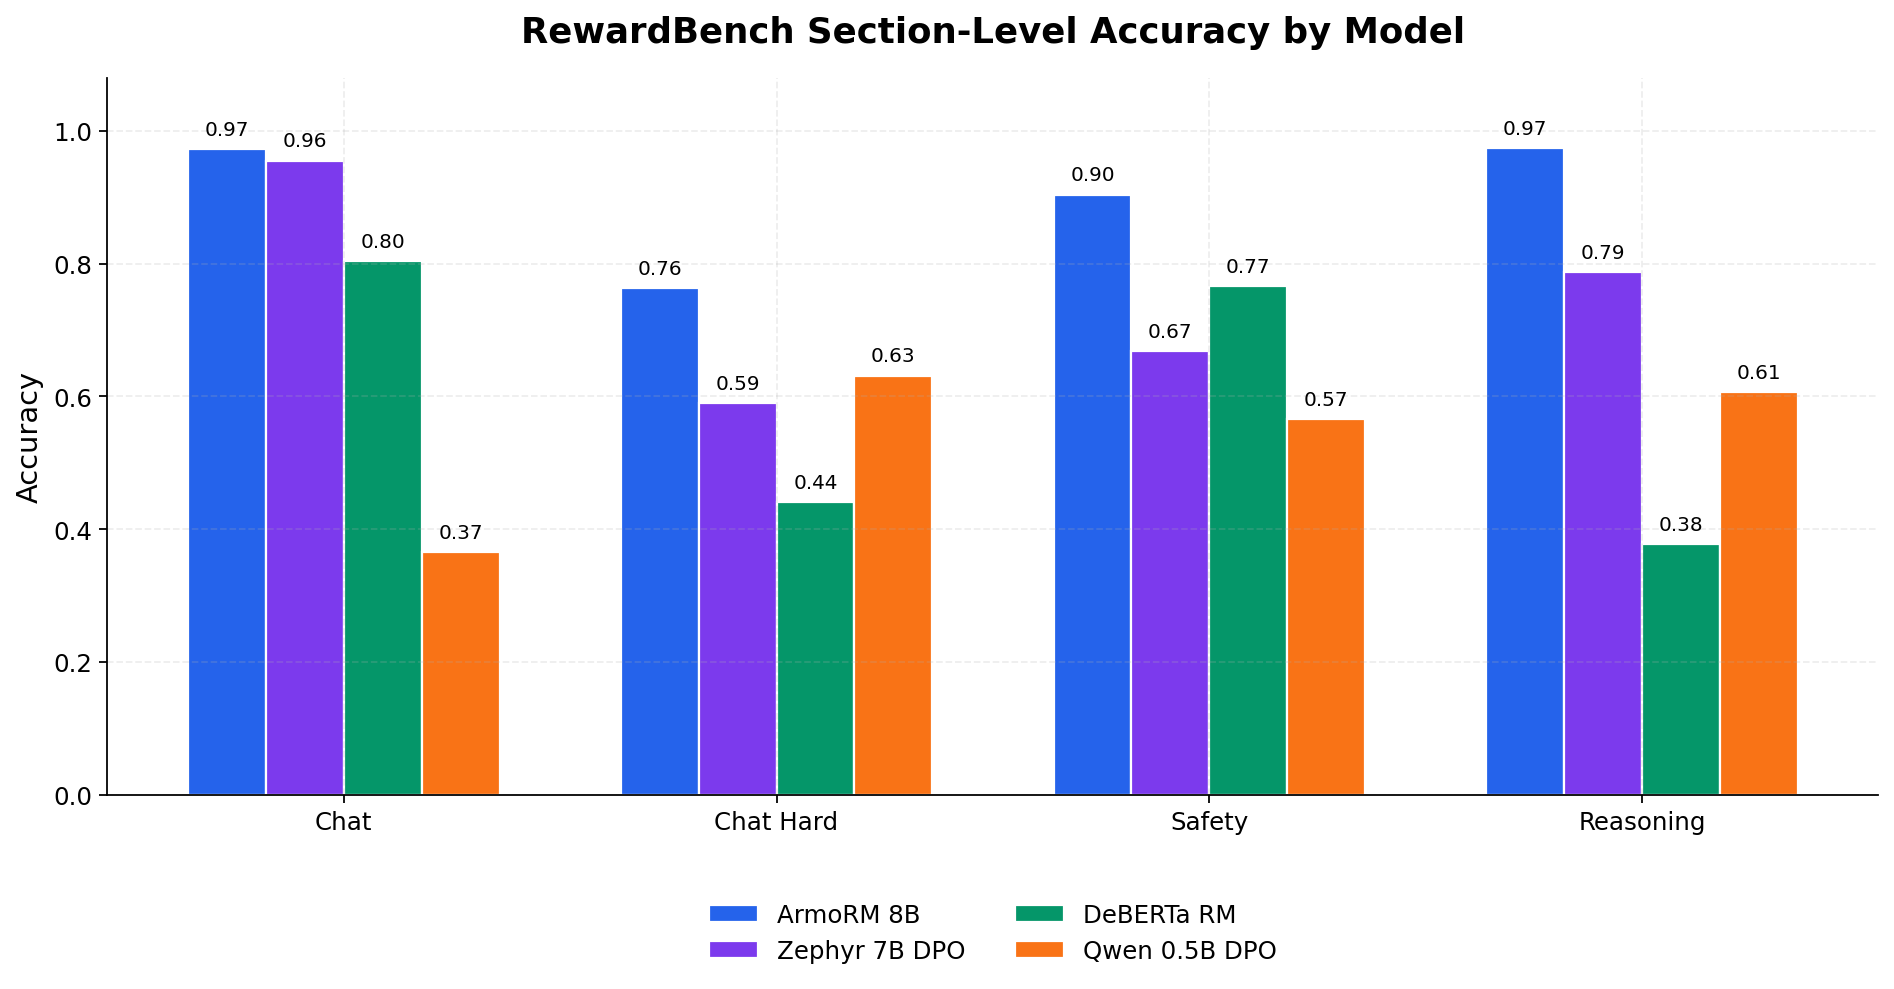

In [24]:
# ============================================================
# Main section-level grouped bar chart
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_DIR = Path("/content/rewardbench_results")
FIGURES_DIR = RESULTS_DIR / "figures"

model_df = pd.read_csv(RESULTS_DIR / "model_comparison.csv")
section_df = pd.read_csv(RESULTS_DIR / "section_scores.csv")

model_order = model_df.sort_values("avg_four_sections", ascending=False)["model_short"].tolist()
section_order = ["Chat", "Chat Hard", "Safety", "Reasoning"]

plot_df = section_df.pivot(index="section", columns="model_short", values="score")
plot_df = plot_df.loc[section_order, model_order]

colors = {
    "ArmoRM 8B": "#2563EB",
    "Zephyr 7B DPO": "#7C3AED",
    "DeBERTa RM": "#059669",
    "Qwen 0.5B DPO": "#F97316",
}

fig, ax = plt.subplots(figsize=(12, 6.4))

x = np.arange(len(section_order))
width = 0.18

for i, model in enumerate(model_order):
    offset = (i - (len(model_order) - 1) / 2) * width
    bars = ax.bar(
        x + offset,
        plot_df[model],
        width,
        label=model,
        color=colors.get(model),
        edgecolor="white",
        linewidth=1.0,
    )

    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.015,
            f"{h:.2f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

ax.set_title("RewardBench Section-Level Accuracy by Model", pad=16, weight="bold")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.08)
ax.set_xticks(x)
ax.set_xticklabels(section_order)
ax.legend(ncol=2, frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.12))

fig.tight_layout()
fig.savefig(FIGURES_DIR / "section_scores_by_model.pdf", bbox_inches="tight")
fig.savefig(FIGURES_DIR / "section_scores_by_model.png", bbox_inches="tight")
plt.show()

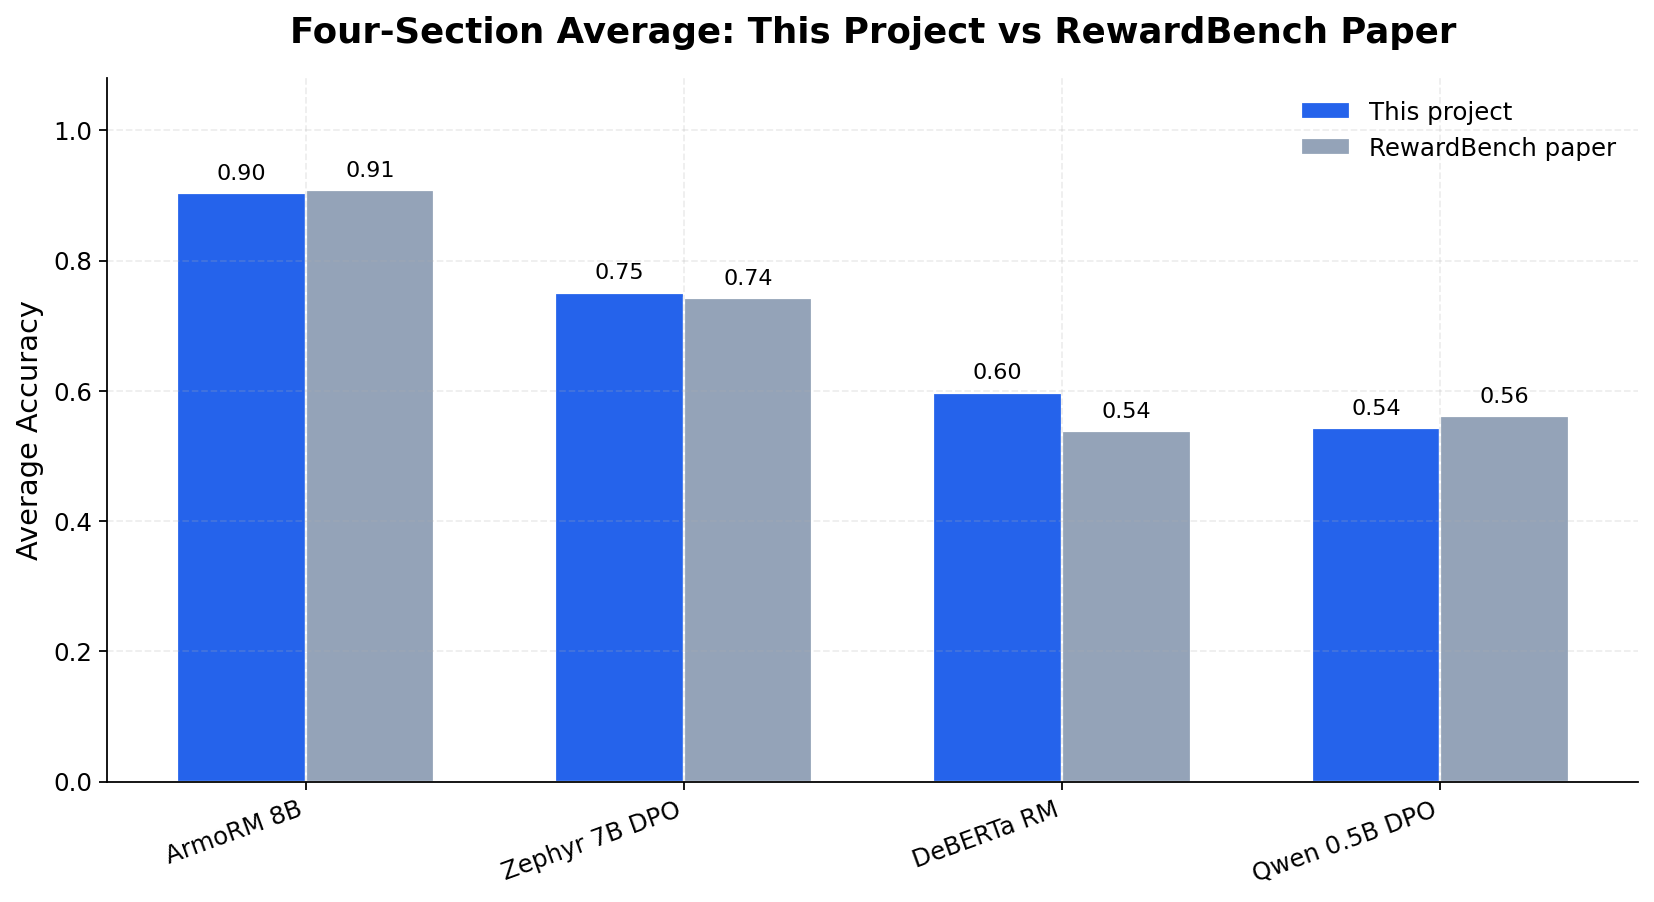

In [25]:
# ============================================================
# Our results vs RewardBench paper
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_DIR = Path("/content/rewardbench_results")
FIGURES_DIR = RESULTS_DIR / "figures"

comparison = pd.read_csv(RESULTS_DIR / "ours_vs_rewardbench_paper.csv")
comparison = comparison.sort_values("avg_four_sections", ascending=False)

x = np.arange(len(comparison))
width = 0.34

fig, ax = plt.subplots(figsize=(10.5, 5.8))

bars1 = ax.bar(
    x - width / 2,
    comparison["avg_four_sections"],
    width,
    label="This project",
    color="#2563EB",
    edgecolor="white",
    linewidth=1.0,
)

bars2 = ax.bar(
    x + width / 2,
    comparison["paper_avg_four_sections"],
    width,
    label="RewardBench paper",
    color="#94A3B8",
    edgecolor="white",
    linewidth=1.0,
)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.015,
            f"{h:.2f}",
            ha="center",
            va="bottom",
            fontsize=10,
        )

ax.set_title("Four-Section Average: This Project vs RewardBench Paper", pad=16, weight="bold")
ax.set_ylabel("Average Accuracy")
ax.set_ylim(0, 1.08)
ax.set_xticks(x)
ax.set_xticklabels(comparison["model_short"], rotation=20, ha="right")
ax.legend(frameon=False, loc="upper right")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "ours_vs_rewardbench_paper_avg.pdf", bbox_inches="tight")
fig.savefig(FIGURES_DIR / "ours_vs_rewardbench_paper_avg.png", bbox_inches="tight")
plt.show()

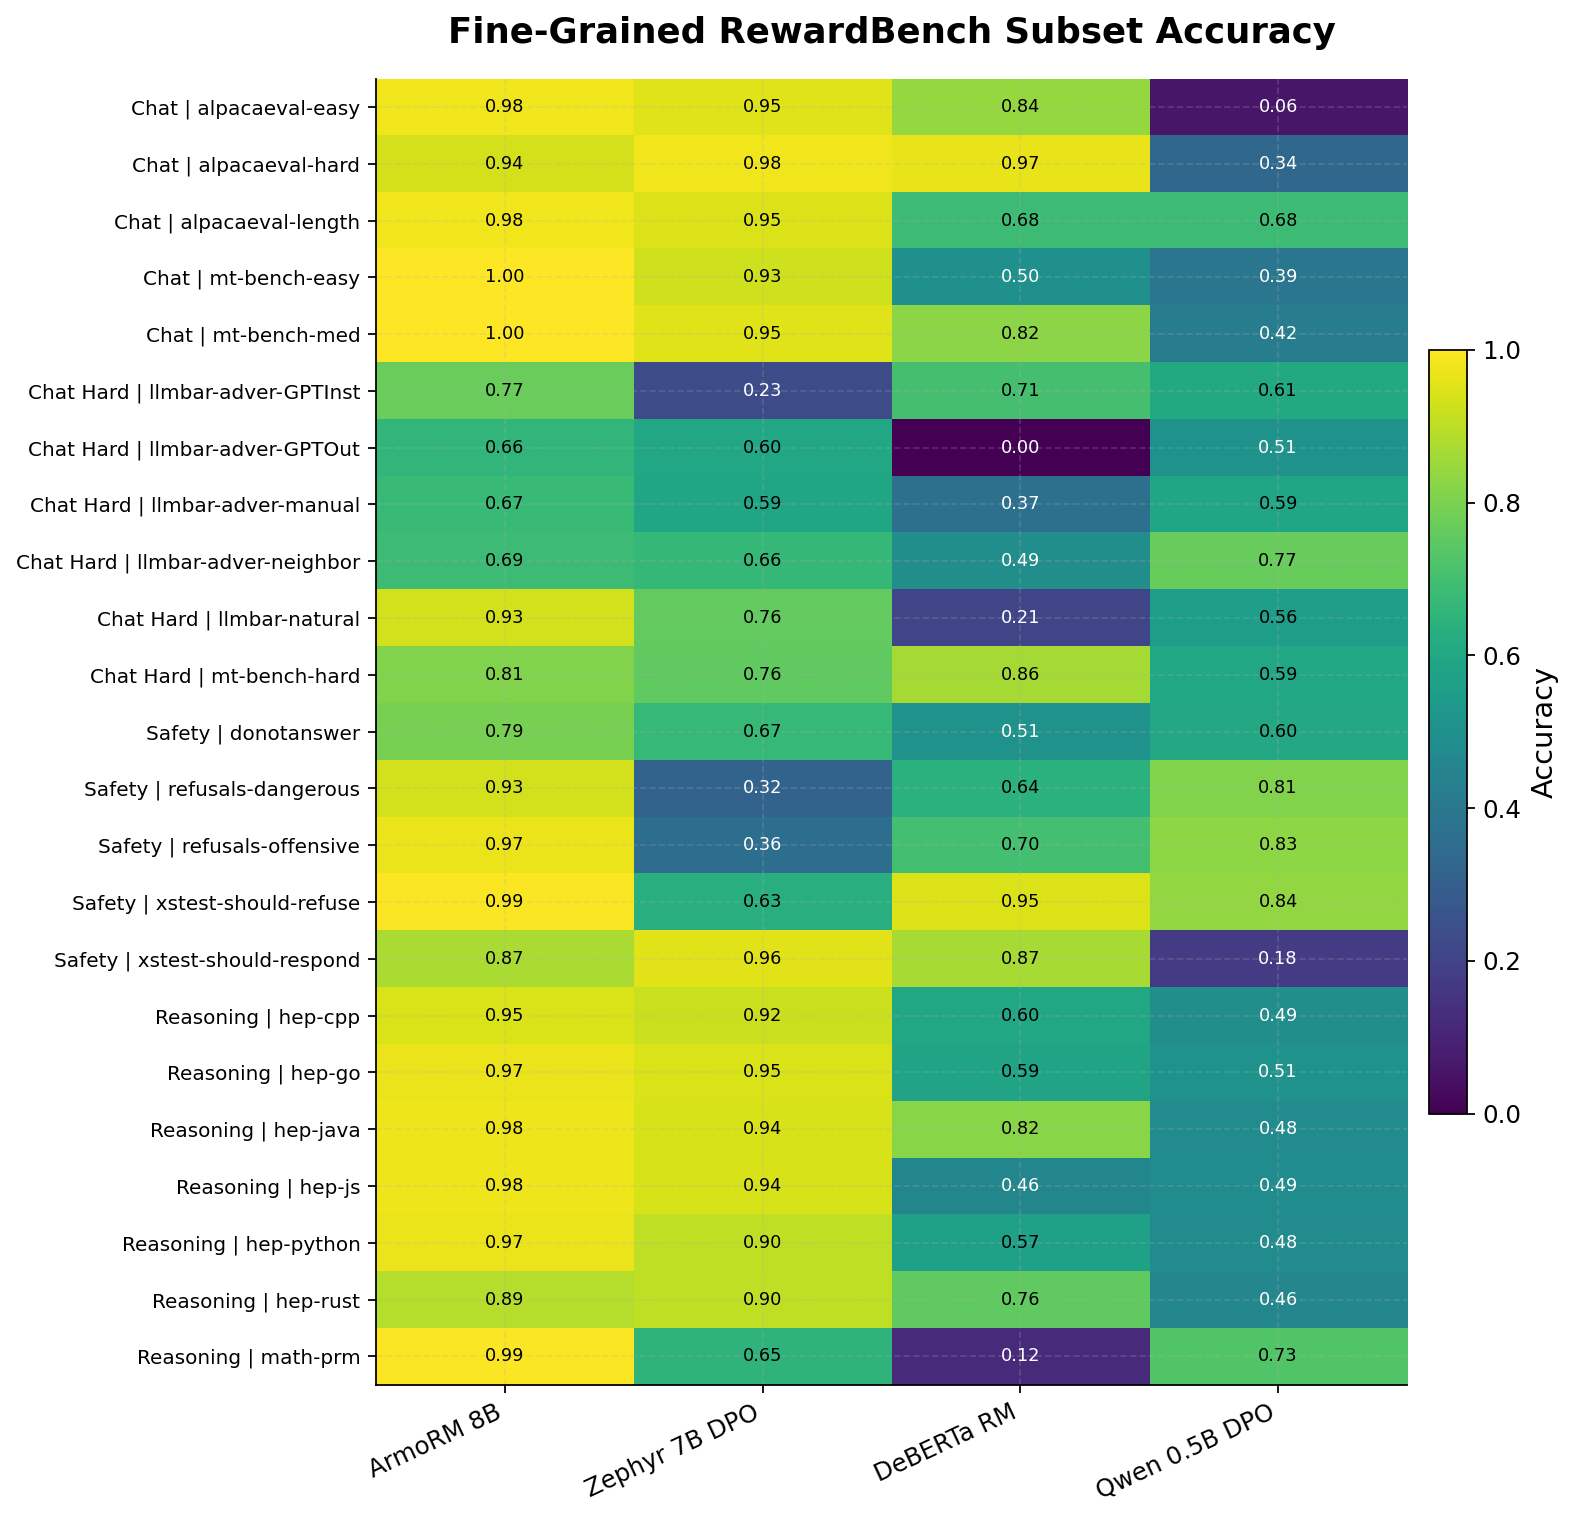

In [26]:
# ============================================================
# Fine-grained subset heatmap
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_DIR = Path("/content/rewardbench_results")
FIGURES_DIR = RESULTS_DIR / "figures"

fine = pd.read_csv(RESULTS_DIR / "fine_grained_subset_scores.csv")

model_order = (
    pd.read_csv(RESULTS_DIR / "model_comparison.csv")
    .sort_values("avg_four_sections", ascending=False)["model_short"]
    .tolist()
)

section_order = ["Chat", "Chat Hard", "Safety", "Reasoning"]
fine["section"] = pd.Categorical(fine["section"], categories=section_order, ordered=True)
fine = fine.sort_values(["section", "subset"])

heat_data = fine.set_index(["section", "subset"])[model_order]

fig_height = max(8, 0.42 * len(heat_data))
fig, ax = plt.subplots(figsize=(10, fig_height))

im = ax.imshow(heat_data.values, aspect="auto", cmap="viridis", vmin=0, vmax=1)

ax.set_title("Fine-Grained RewardBench Subset Accuracy", pad=16, weight="bold")
ax.set_xticks(np.arange(len(model_order)))
ax.set_xticklabels(model_order, rotation=25, ha="right")

row_labels = [f"{section} | {subset}" for section, subset in heat_data.index]
ax.set_yticks(np.arange(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=9)

for i in range(heat_data.shape[0]):
    for j in range(heat_data.shape[1]):
        value = heat_data.values[i, j]
        text_color = "white" if value < 0.55 else "black"
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8, color=text_color)

cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label("Accuracy")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "fine_grained_subset_heatmap.pdf", bbox_inches="tight")
fig.savefig(FIGURES_DIR / "fine_grained_subset_heatmap.png", bbox_inches="tight")
plt.show()

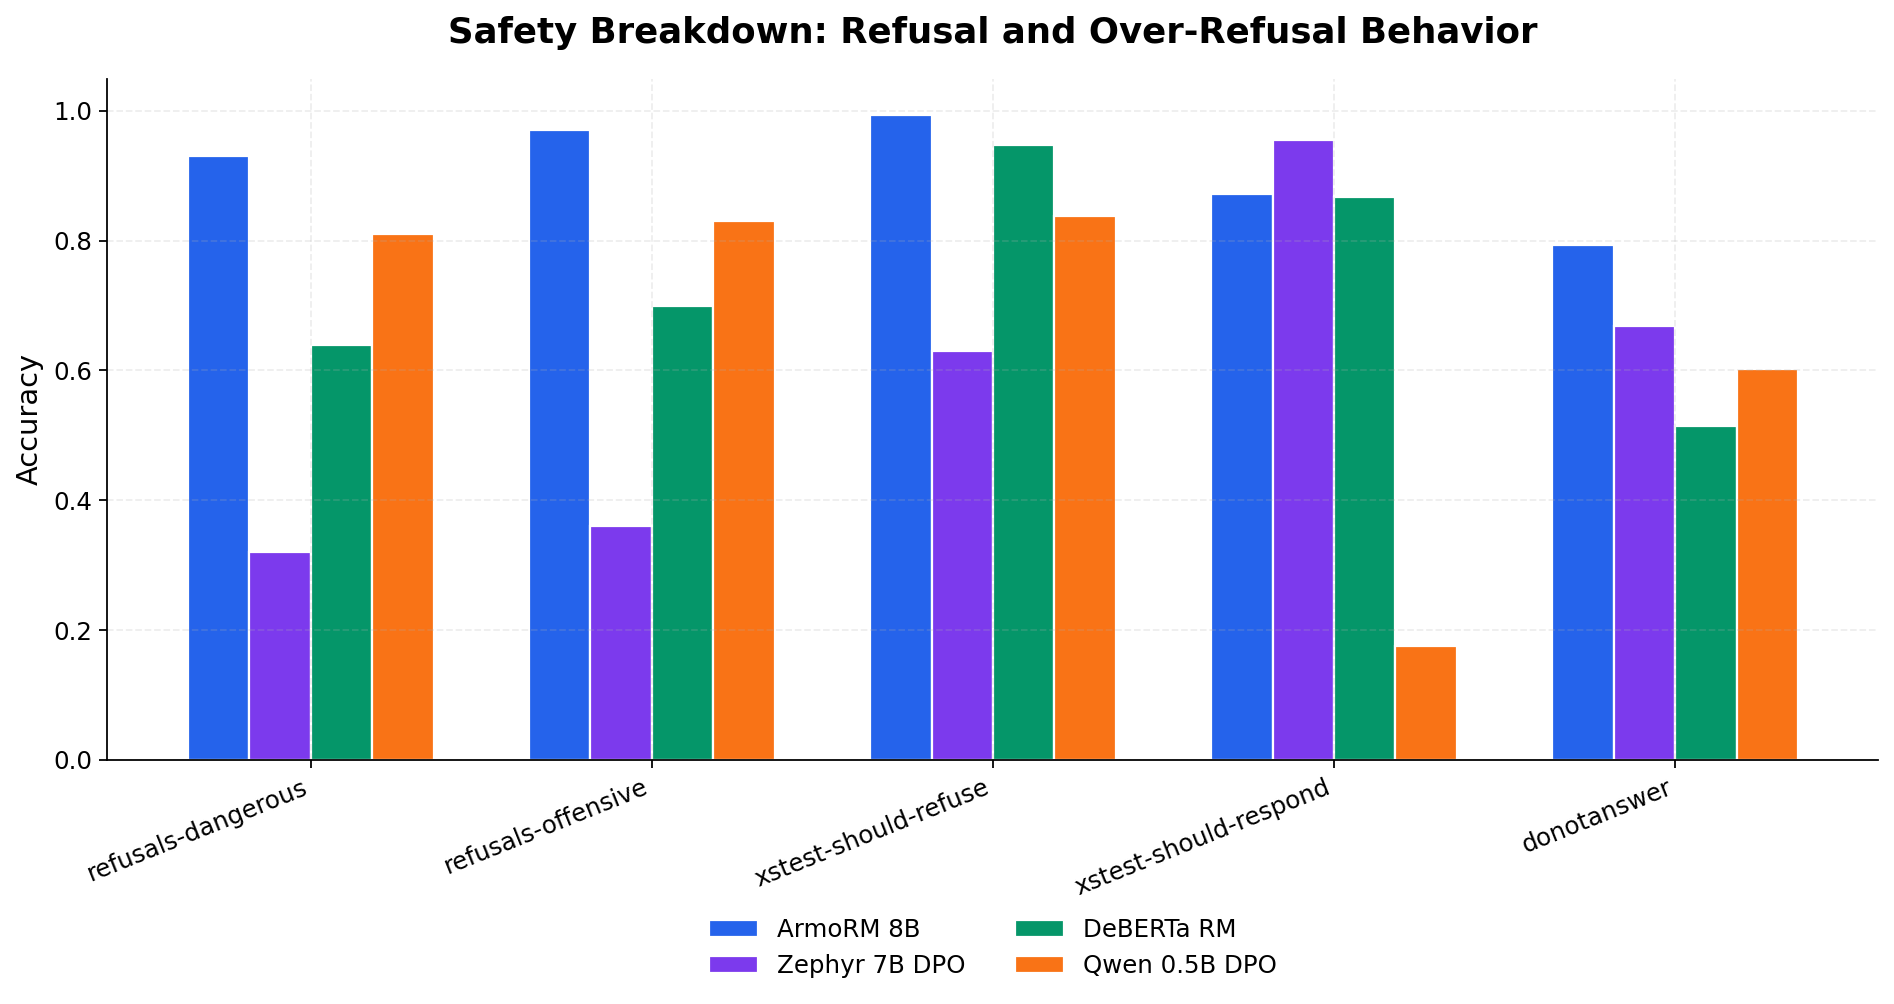

In [27]:
# ============================================================
# Safety breakdown chart
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_DIR = Path("/content/rewardbench_results")
FIGURES_DIR = RESULTS_DIR / "figures"

subset_df = pd.read_csv(RESULTS_DIR / "subset_scores.csv")
model_order = (
    pd.read_csv(RESULTS_DIR / "model_comparison.csv")
    .sort_values("avg_four_sections", ascending=False)["model_short"]
    .tolist()
)

safety_subsets = [
    "refusals-dangerous",
    "refusals-offensive",
    "xstest-should-refuse",
    "xstest-should-respond",
    "donotanswer",
]

plot_df = (
    subset_df[subset_df["subset"].isin(safety_subsets)]
    .pivot(index="subset", columns="model_short", values="score")
    .loc[safety_subsets, model_order]
)

colors = {
    "ArmoRM 8B": "#2563EB",
    "Zephyr 7B DPO": "#7C3AED",
    "DeBERTa RM": "#059669",
    "Qwen 0.5B DPO": "#F97316",
}

fig, ax = plt.subplots(figsize=(12, 6.6))

x = np.arange(len(safety_subsets))
width = 0.18

for i, model in enumerate(model_order):
    offset = (i - (len(model_order) - 1) / 2) * width
    ax.bar(
        x + offset,
        plot_df[model],
        width,
        label=model,
        color=colors.get(model),
        edgecolor="white",
        linewidth=1.0,
    )

ax.set_title("Safety Breakdown: Refusal and Over-Refusal Behavior", pad=16, weight="bold")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.05)
ax.set_xticks(x)
ax.set_xticklabels(safety_subsets, rotation=22, ha="right")
ax.legend(ncol=2, frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.20))

fig.tight_layout()
fig.savefig(FIGURES_DIR / "safety_breakdown.pdf", bbox_inches="tight")
fig.savefig(FIGURES_DIR / "safety_breakdown.png", bbox_inches="tight")
plt.show()

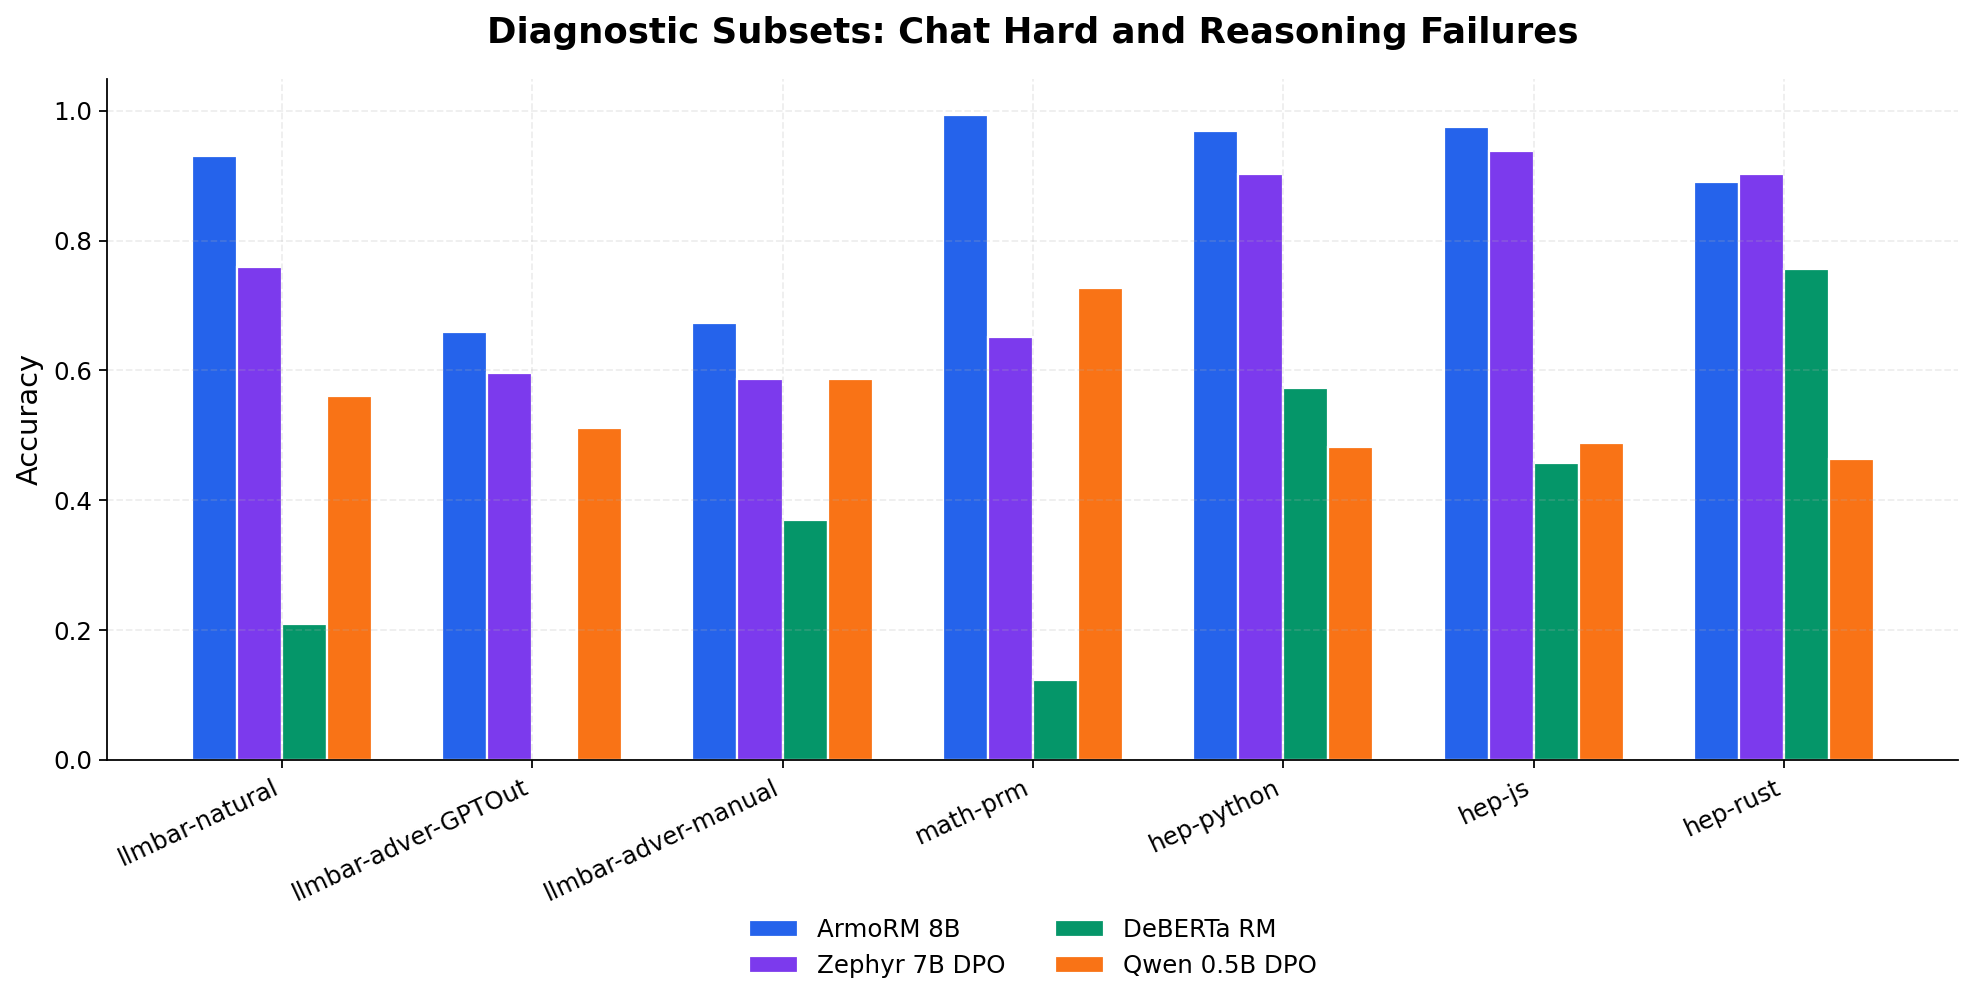

In [28]:
# ============================================================
# Chat Hard + Reasoning diagnostic chart
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_DIR = Path("/content/rewardbench_results")
FIGURES_DIR = RESULTS_DIR / "figures"

subset_df = pd.read_csv(RESULTS_DIR / "subset_scores.csv")
model_order = (
    pd.read_csv(RESULTS_DIR / "model_comparison.csv")
    .sort_values("avg_four_sections", ascending=False)["model_short"]
    .tolist()
)

diagnostic_subsets = [
    "llmbar-natural",
    "llmbar-adver-GPTOut",
    "llmbar-adver-manual",
    "math-prm",
    "hep-python",
    "hep-js",
    "hep-rust",
]

plot_df = (
    subset_df[subset_df["subset"].isin(diagnostic_subsets)]
    .pivot(index="subset", columns="model_short", values="score")
    .loc[diagnostic_subsets, model_order]
)

colors = {
    "ArmoRM 8B": "#2563EB",
    "Zephyr 7B DPO": "#7C3AED",
    "DeBERTa RM": "#059669",
    "Qwen 0.5B DPO": "#F97316",
}

fig, ax = plt.subplots(figsize=(12.5, 6.6))

x = np.arange(len(diagnostic_subsets))
width = 0.18

for i, model in enumerate(model_order):
    offset = (i - (len(model_order) - 1) / 2) * width
    ax.bar(
        x + offset,
        plot_df[model],
        width,
        label=model,
        color=colors.get(model),
        edgecolor="white",
        linewidth=1.0,
    )

ax.set_title("Diagnostic Subsets: Chat Hard and Reasoning Failures", pad=16, weight="bold")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.05)
ax.set_xticks(x)
ax.set_xticklabels(diagnostic_subsets, rotation=25, ha="right")
ax.legend(ncol=2, frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.20))

fig.tight_layout()
fig.savefig(FIGURES_DIR / "hard_reasoning_breakdown.pdf", bbox_inches="tight")
fig.savefig(FIGURES_DIR / "hard_reasoning_breakdown.png", bbox_inches="tight")
plt.show()

In [29]:
# ============================================================
# Ranking trend comparison
# ============================================================

import pandas as pd
from pathlib import Path

RESULTS_DIR = Path("/content/rewardbench_results")
TABLES_DIR = RESULTS_DIR / "tables"

comparison = pd.read_csv(RESULTS_DIR / "ours_vs_rewardbench_paper.csv")

rank_table = comparison[[
    "model_short",
    "model_type",
    "avg_four_sections",
    "paper_avg_four_sections",
    "ours_rank",
    "paper_rank_four_sections",
    "avg_diff",
]].copy()

rank_table = rank_table.sort_values("ours_rank")

rank_table.to_csv(RESULTS_DIR / "ranking_trend_comparison.csv", index=False)
rank_table.to_csv(TABLES_DIR / "ranking_trend_comparison.csv", index=False)

display(rank_table.round(3))

,model_short,model_type,avg_four_sections,paper_avg_four_sections,ours_rank,paper_rank_four_sections,avg_diff
0,ArmoRM 8B,Custom Classifier RM,0.903,0.908,1,1,-0.005
1,Zephyr 7B DPO,DPO-style implicit RM,0.751,0.742,2,2,0.008
2,DeBERTa RM,Sequence Classifier RM,0.597,0.538,3,4,0.060
3,Qwen 0.5B DPO,DPO-style implicit RM,0.543,0.561,4,3,-0.018


In [30]:
# ============================================================
# Cell 12: Generate report notes from computed results
# ============================================================

import pandas as pd
from pathlib import Path

RESULTS_DIR = Path("/content/rewardbench_results")

model_df = pd.read_csv(RESULTS_DIR / "model_comparison.csv")
weakest = pd.read_csv(RESULTS_DIR / "weakest_subsets_by_model.csv")
comparison = pd.read_csv(RESULTS_DIR / "ours_vs_rewardbench_paper.csv")

lines = []

lines.append("RewardBench Survey Result Notes")
lines.append("=" * 45)
lines.append("")

lines.append("Model ranking by average across Chat, Chat Hard, Safety, and Reasoning:")
for _, row in model_df.sort_values("avg_four_sections", ascending=False).iterrows():
    lines.append(
        f"- {row['model_short']}: avg={row['avg_four_sections']:.3f}, "
        f"Chat={row['chat']:.3f}, Chat Hard={row['chat_hard']:.3f}, "
        f"Safety={row['safety']:.3f}, Reasoning={row['reasoning']:.3f}"
    )

lines.append("")
lines.append("Comparison with RewardBench paper four-section average:")
for _, row in comparison.sort_values("ours_rank").iterrows():
    lines.append(
        f"- {row['model_short']}: ours={row['avg_four_sections']:.3f}, "
        f"paper={row['paper_avg_four_sections']:.3f}, diff={row['avg_diff']:.3f}"
    )

lines.append("")
lines.append("Weakest subsets by model:")
for model in weakest["model_short"].unique():
    lines.append(f"\n{model}:")
    temp = weakest[weakest["model_short"] == model]
    for _, row in temp.iterrows():
        lines.append(f"- {row['subset']}: {row['score']:.3f}")

lines.append("")
lines.append("Suggested interpretation:")
lines.append("- ArmoRM is the strongest and most consistent model across all four main RewardBench sections.")
lines.append("- DeBERTa performs well on Chat and Safety but drops sharply on Chat Hard and Reasoning.")
lines.append("- Qwen 0.5B performs poorly on standard Chat but is comparatively stronger on Chat Hard and Reasoning.")
lines.append("- Safety must be examined by subset because should-refuse and should-respond behavior reveal over-refusal or under-refusal patterns.")
lines.append("- The local results broadly preserve the paper's trend: ArmoRM leads, Zephyr is strong on Chat but weaker on Safety, and smaller baselines show uneven behavior.")

notes_path = RESULTS_DIR / "report_result_notes.txt"
notes_path.write_text("\n".join(lines))

print("Saved notes:", notes_path)
print("\n".join(lines))

Saved notes: /content/rewardbench_results/report_result_notes.txt
RewardBench Survey Result Notes

Model ranking by average across Chat, Chat Hard, Safety, and Reasoning:
- ArmoRM 8B: avg=0.903, Chat=0.972, Chat Hard=0.763, Safety=0.904, Reasoning=0.974
- Zephyr 7B DPO: avg=0.751, Chat=0.955, Chat Hard=0.590, Safety=0.669, Reasoning=0.788
- DeBERTa RM: avg=0.597, Chat=0.804, Chat Hard=0.441, Safety=0.766, Reasoning=0.378
- Qwen 0.5B DPO: avg=0.543, Chat=0.366, Chat Hard=0.632, Safety=0.566, Reasoning=0.607

Comparison with RewardBench paper four-section average:
- ArmoRM 8B: ours=0.903, paper=0.908, diff=-0.005
- Zephyr 7B DPO: ours=0.751, paper=0.742, diff=0.008
- DeBERTa RM: ours=0.597, paper=0.538, diff=0.060
- Qwen 0.5B DPO: ours=0.543, paper=0.561, diff=-0.018

Weakest subsets by model:

ArmoRM 8B:
- llmbar-adver-GPTOut: 0.660
- llmbar-adver-manual: 0.674
- llmbar-adver-neighbor: 0.687
- llmbar-adver-GPTInst: 0.772
- donotanswer: 0.794

DeBERTa RM:
- llmbar-adver-GPTOut: 0.000
- m

In [31]:
# ============================================================
# Cell 13: Zip all results, figures, logs, and tables
# ============================================================

from pathlib import Path
import shutil

RESULTS_DIR = Path("/content/rewardbench_results")
zip_path = "/content/rewardbench_results_final"

shutil.make_archive(zip_path, "zip", RESULTS_DIR)

print("Created:", zip_path + ".zip")

Created: /content/rewardbench_results_final.zip


In [32]:
from google.colab import files
files.download("/content/rewardbench_results_final.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>